<a href="https://colab.research.google.com/github/cathrineq/python-ai-Tarasova-Kate/blob/main/notebooks/viz1_currency_clusters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование и загрузка

**Что делаем:**
- Клонируем репозиторий `python-ai-Tarasova-Kate` в Colab
- Загружаем 2 CSV-файла из Wikidata:
  - `currency_rates.csv` — курсы валют (P2284) с метками времени (P585, P580)
  - `countries_currencies.csv` — страны + официальные валюты (P38, P1082, P2046)
- Очищаем данные:
  - 🔗 URL Wikidata → переименовываем (`URL`, `country_URL`, `currency_URL`) — **не удаляем!**
  - 🏷️ `*Label` → короткие имена (`currency`, `unit`, `country`)
  - 📊 Числовые поля → `float`, пропуски (`NaN`) **не заменяем на 0**
  - 📈 Измеряем заполненность `OPTIONAL`-полей перед очисткой

**Результат:**

📊 `df_rates` — курсы валют по времени
| Столбец | Описание |
|---------|----------|
| `URL` | Ссылка на валюту в Wikidata 🔑 |
| `currency` | Название валюты |
| `price` | Курс в евро (float, возможны NaN) |
| `year` / `startYear` | Год данных (float, возможны NaN) |
| `unit` / `unitSymbol` | Единица измерения и символ |

🌍 `df_countries` — страны и их валюты
| Столбец | Описание |
|---------|----------|
| `country_URL` | Ссылка на страну в Wikidata |
| `country` | Название страны |
| `currency_URL` | Ссылка на валюту 🔑 (ключ для `merge`) |
| `currency` | Название валюты |
| `population` / `area` | Население и площадь (float, возможны NaN) |

> 💡 **Важно:** Столбцы `URL` / `currency_URL` сохранены для:  
> 1) отладки аномалий (клик → запись в Wikidata)  
> 2) надёжного объединения таблиц через `pd.merge(on="currency_URL")`

In [2]:
# ============================================================
#  ЯЧЕЙКА 1: Подготовка данных (для viz1 и viz2)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Клонируем репозиторий (если ещё не клонирован)
repo = "python-ai-Tarasova-Kate"
repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/cathrineq/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

# 2. Загружаем сырые CSV-файлы
df_rates_raw = pd.read_csv("data/currency_rates.csv")
df_countries_raw = pd.read_csv("data/countries_currencies.csv")

# 3. Очистка и переименование столбцов для df_rates (как в задании 2)
df_rates = df_rates_raw.rename(columns={
    "currency": "URL",
    "currencyLabel": "currency",
    "unitLabel": "unit"
}, errors="ignore")

# Приводим числовые столбцы к float (NaN, если не число)
df_rates["price"] = pd.to_numeric(df_rates["price"], errors="coerce")
if "year" in df_rates.columns:
    df_rates["year"] = pd.to_numeric(df_rates["year"], errors="coerce")
if "startYear" in df_rates.columns:
    df_rates["startYear"] = pd.to_numeric(df_rates["startYear"], errors="coerce")

# 4. Очистка для df_countries (переименовываем URL и Label)
df_countries = df_countries_raw.rename(columns={
    "country": "country_URL",
    "currency": "currency_URL",
    "countryLabel": "country",
    "currencyLabel": "currency"
}, errors="ignore")

# Приводим числовые столбцы
df_countries["population"] = pd.to_numeric(df_countries["population"], errors="coerce")
df_countries["area"] = pd.to_numeric(df_countries["area"], errors="coerce")

# 5. Документируем выбросы по цене (очень большие значения)
outliers = df_rates[df_rates["price"] >= 1e8]  # 100 миллионов и больше
if len(outliers) > 0:
    print("⚠️ ВНИМАНИЕ: Обнаружены выбросы по цене (≥ 100 000 000 евро):")
    print(outliers[["URL", "currency", "price", "year", "unit"]].to_string())
    print("\nЭти выбросы могут искажать цветовую шкалу на графиках.")
    print("В viz1 мы их временно исключим (оставим только цены < 1e8).\n")
else:
    print("✅ Выбросов по цене не обнаружено.\n")

# 6. Создаём df_unique_countries (уникальные страны, агрегированные)
#    Это нужно для второй визуализации (карта с дугами), но можно создать сразу.
df_unique_countries = (
    df_countries
    .groupby("country_URL")
    .agg(
        country=("country", "first"),               # название страны
        n_currencies=("currency_URL", "nunique"),  # сколько разных валют было у страны
        population=("population", "max"),          # население (берём максимум, если несколько записей)
        area=("area", "max")                       # площадь
    )
    .reset_index()
)
print(f"✅ df_unique_countries: {len(df_unique_countries)} уникальных стран (из {len(df_countries)} строк)")

# 7. Краткая информация о данных (для проверки)
print("\n📊 df_rates:", df_rates.shape)
print("Столбцы:", df_rates.columns.tolist())
print("\n📊 df_countries:", df_countries.shape)
print("Столбцы:", df_countries.columns.tolist())
print("\n✅ Подготовка данных завершена.")

/content/python-ai-Tarasova-Kate
⚠️ ВНИМАНИЕ: Обнаружены выбросы по цене (≥ 100 000 000 евро):
                                           URL            currency         price    year                   unit
523   http://www.wikidata.org/entity/Q56349362  Суверенный боливар  1.000000e+08  2018.0  венесуэльский боливар
526   http://www.wikidata.org/entity/Q56349362  Суверенный боливар  1.000000e+08  2018.0  венесуэльский боливар
529   http://www.wikidata.org/entity/Q56349362  Суверенный боливар  1.000000e+08  2018.0  венесуэльский боливар
1417    http://www.wikidata.org/entity/Q260447       рентная марка  1.000000e+09  1923.0             рейхсмарка

Эти выбросы могут искажать цветовую шкалу на графиках.
В viz1 мы их временно исключим (оставим только цены < 1e8).

✅ df_unique_countries: 209 уникальных стран (из 803 строк)

📊 df_rates: (2346, 8)
Столбцы: ['URL', 'currency', 'shortName', 'price', 'year', 'startYear', 'unit', 'unitSymbol']

📊 df_countries: (803, 7)
Столбцы: ['country_URL', '

In [5]:
# ДИАГНОСТИКА: смотрим, что у нас в df_eur
print("Уникальные значения unit в df_eur:", df_eur["unit"].unique())
print("Колонки в df_eur:", df_eur.columns.tolist())
print("Пример best_year, year, startYear:")
print(df_eur[["currency", "best_year", "year", "startYear"]].head(10))
print("Диапазон best_year:", df_eur["best_year"].min(), "-", df_eur["best_year"].max())
print("Количество уникальных валют:", df_eur["currency"].nunique())

# Посмотрим, сколько записей на валюту
currency_counts = df_eur.groupby("currency").size()
print("Валют с >=2 записями:", (currency_counts >= 2).sum())
print("Валют с >=5 записями:", (currency_counts >= 5).sum())

# Проверим временные интервалы
if USE_DECADES:
    df_eur["time_bin"] = (df_eur["best_year"] // 10 * 10).astype(int)
else:
    df_eur["time_bin"] = df_eur["best_year"]
print("Уникальные временные интервалы:", sorted(df_eur["time_bin"].unique()))

Уникальные значения unit в df_eur: ['евро']
Колонки в df_eur: ['URL', 'currency', 'shortName', 'price', 'year', 'startYear', 'unit', 'unitSymbol', 'best_year', 'log_price', 'time_bin']
Пример best_year, year, startYear:
                    currency  best_year    year  startYear
0                  вона КНДР     2018.0  2018.0        NaN
1             шведская крона     2018.0  2018.0        NaN
3            польский злотый     2018.0  2018.0        NaN
4            польский злотый     2020.0  2020.0        NaN
5              албанский лек     2019.0  2019.0        NaN
6             армянский драм     2019.0  2019.0        NaN
8              чешская крона     2018.0  2018.0        NaN
9              чешская крона     2025.0  2025.0        NaN
10  новый израильский шекель     2020.0  2020.0        NaN
13  новый израильский шекель     2020.0  2020.0        NaN
Диапазон best_year: 1999.0 - 2026.0
Количество уникальных валют: 98
Валют с >=2 записями: 45
Валют с >=5 записями: 7
Уникальные вре

In [8]:
# ДИАГНОСТИКА
df_rates_clust = df_rates.copy()
df_rates_clust["best_year"] = df_rates_clust["year"].fillna(df_rates_clust["startYear"])
df_eur = df_rates_clust[
    (df_rates_clust["unit"] == "евро") &
    (df_rates_clust["best_year"].notna()) &
    (df_rates_clust["price"] > 0) &
    (df_rates_clust["price"] < 1e8)
].copy()
df_eur["log_price"] = np.log10(df_eur["price"])
df_eur["decade"] = (df_eur["best_year"] // 10 * 10).astype(int)

pivot_full = df_eur.pivot_table(index="currency", columns="decade", values="log_price", aggfunc="mean")
print("Размер сводной таблицы (все данные):", pivot_full.shape)
print("Десятилетия:", sorted(pivot_full.columns))
print("Количество валют с данными в каждом десятилетии:")
for col in sorted(pivot_full.columns):
    print(f"  {col}: {pivot_full[col].notna().sum()} валют")
print("\nРаспределение валют по числу десятилетий с данными:")
counts = pivot_full.notna().sum(axis=1).value_counts().sort_index()
for k, v in counts.items():
    print(f"  {k} десятилетий(я): {v} валют")

Размер сводной таблицы (все данные): (98, 4)
Десятилетия: [1990, 2000, 2010, 2020]
Количество валют с данными в каждом десятилетии:
  1990: 2 валют
  2000: 4 валют
  2010: 39 валют
  2020: 62 валют

Распределение валют по числу десятилетий с данными:
  1 десятилетий(я): 90 валют
  2 десятилетий(я): 7 валют
  3 десятилетий(я): 1 валют


#🌟Кластеризованная тепловая карта (clustermap)


Размер сводной таблицы: (8, 4)
Финальная матрица: (8, 4)
Континенты валют: {'Европа', 'Другое'}


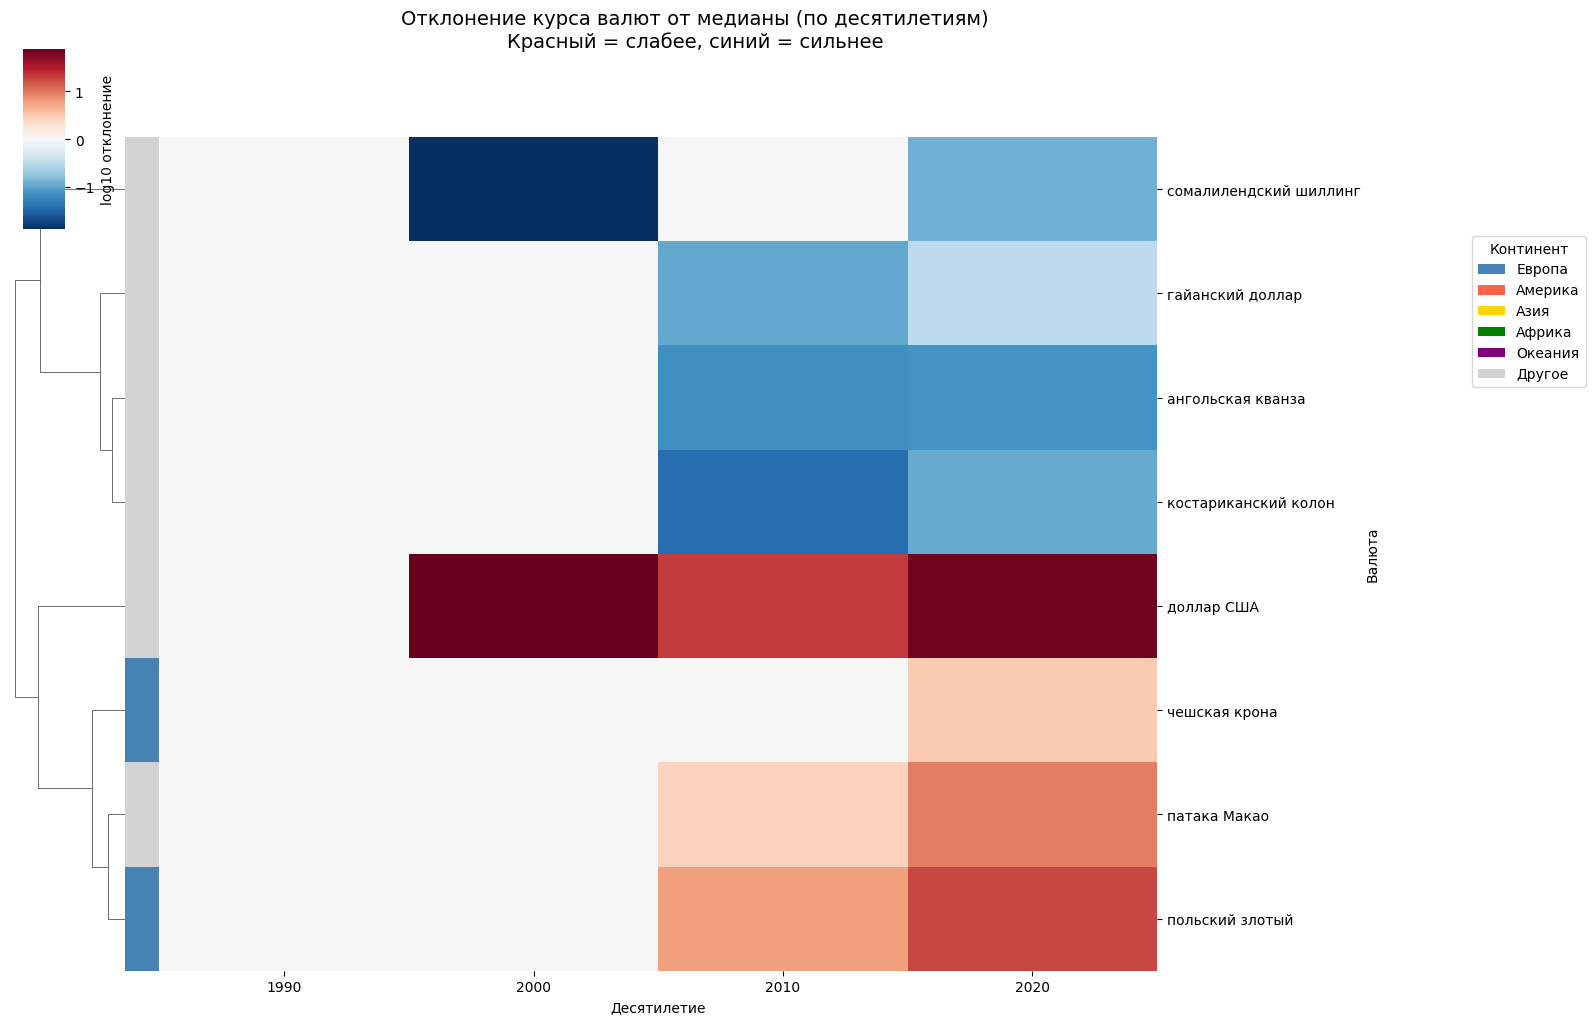

✅ Визуализация построена.


In [9]:
# ============================================================
#  ЯЧЕЙКА 2: Clustermap – итоговый (МИНИМУМ 2 ДЕСЯТИЛЕТИЯ)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# ------------------- НАСТРОЙКИ -------------------
USE_DECADES = True
USE_DEVIATION = True
REMOVE_OUTLIERS = True
MIN_POINTS_PER_CURRENCY = 2   # валюта должна иметь данные хотя бы в 2 десятилетиях

# 1. Подготовка данных
df_rates_clust = df_rates.copy()
df_rates_clust["best_year"] = df_rates_clust["year"].fillna(df_rates_clust["startYear"])

df_eur = df_rates_clust[
    (df_rates_clust["unit"] == "евро") &
    (df_rates_clust["best_year"].notna()) &
    (df_rates_clust["price"] > 0)
].copy()

if REMOVE_OUTLIERS:
    df_eur = df_eur[df_eur["price"] < 1e8]

df_eur["log_price"] = np.log10(df_eur["price"])
if USE_DECADES:
    df_eur["time_bin"] = (df_eur["best_year"] // 10 * 10).astype(int)
    time_label = "Десятилетие"
else:
    df_eur["time_bin"] = df_eur["best_year"]
    time_label = "Год"

pivot = df_eur.pivot_table(index="currency", columns="time_bin", values="log_price", aggfunc="mean")

# Оставляем валюты с достаточным числом временных точек
pivot = pivot.dropna(thresh=MIN_POINTS_PER_CURRENCY, axis=0)

# НЕ УДАЛЯЕМ столбцы (временные интервалы) – оставляем все
print(f"Размер сводной таблицы: {pivot.shape}")

if pivot.shape[0] < 2:
    raise ValueError("Меньше 2 валют. Уменьшите MIN_POINTS_PER_CURRENCY до 1 (но тогда будет 1 валюта).")
if pivot.shape[1] < 2:
    print("Временных интервалов меньше 2, но продолжим.")

# Нормализация: отклонение от медианы по каждому году
if USE_DEVIATION:
    pivot_norm = pivot.sub(pivot.median(axis=0), axis=1)
    cmap = "RdBu_r"
    center = 0
    title = "Отклонение курса валют от медианы (по десятилетиям)\nКрасный = слабее, синий = сильнее"
    cbar_label = "log10 отклонение"
else:
    pivot_norm = pivot
    cmap = "viridis"
    center = None
    title = "Абсолютный логарифм курса валют к евро"
    cbar_label = "log10(price)"

# Заполняем пропуски нулём (0 = медиана) и убираем бесконечности
pivot_norm = pivot_norm.fillna(0)
pivot_norm = pivot_norm.replace([np.inf, -np.inf], 0)

# Сортируем столбцы по возрастанию (хронологический порядок)
pivot_norm = pivot_norm.reindex(sorted(pivot_norm.columns), axis=1)

print(f"Финальная матрица: {pivot_norm.shape}")

# 2. Row_colors: континенты для валют (упрощённо)
currency_to_country = df_countries.groupby("currency")["country"].first().to_dict()
continent_map = {
    "Россия": "Европа", "Германия": "Европа", "Франция": "Европа", "Польша": "Европа",
    "Швеция": "Европа", "Норвегия": "Европа", "Чехия": "Европа", "Венгрия": "Европа",
    "Румыния": "Европа", "Болгария": "Европа", "Греция": "Европа", "Португалия": "Европа",
    "Ирландия": "Европа", "Латвия": "Европа", "Литва": "Европа", "Эстония": "Европа",
    "Словакия": "Европа", "Словения": "Европа", "Хорватия": "Европа", "Сербия": "Европа",
    "Албания": "Европа", "Молдова": "Европа", "Украина": "Европа", "Беларусь": "Европа",
    "США": "Америка", "Канада": "Америка", "Мексика": "Америка", "Бразилия": "Америка",
    "Аргентина": "Америка", "Китай": "Азия", "Япония": "Азия", "Индия": "Азия",
    "Турция": "Азия", "Казахстан": "Азия", "Австралия": "Океания", "Египет": "Африка",
    "ЮАР": "Африка", "Нигерия": "Африка"
}
def get_continent(currency):
    country = currency_to_country.get(currency)
    if country and country in continent_map:
        return continent_map[country]
    return "Другое"

continent_colors = {
    "Европа": "steelblue", "Америка": "tomato", "Азия": "gold",
    "Африка": "green", "Океания": "purple", "Другое": "lightgray"
}
row_colors = [continent_colors[get_continent(curr)] for curr in pivot_norm.index]

print("Континенты валют:", set(get_continent(curr) for curr in pivot_norm.index))

# 3. Построение clustermap
g = sns.clustermap(
    pivot_norm,
    cmap=cmap,
    center=center,
    figsize=(14, 10),
    col_cluster=False,        # столбцы в хронологическом порядке
    row_cluster=True,
    row_colors=row_colors,
    dendrogram_ratio=0.1,
    cbar_pos=(0.02, 0.8, 0.03, 0.18),
    cbar_kws={"label": cbar_label}
)

g.ax_heatmap.set_xlabel(time_label)
g.ax_heatmap.set_ylabel("Валюта")
g.fig.suptitle(title, y=1.02, fontsize=14)

# Легенда для континентов
legend_elements = [Patch(facecolor=color, label=cont) for cont, color in continent_colors.items()]
g.fig.legend(handles=legend_elements, title="Континент", bbox_to_anchor=(1.05, 0.8), loc='upper left')

plt.show()
print("✅ Визуализация построена.")